In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-08-17 122421.png to Screenshot 2026-08-17 122421.png


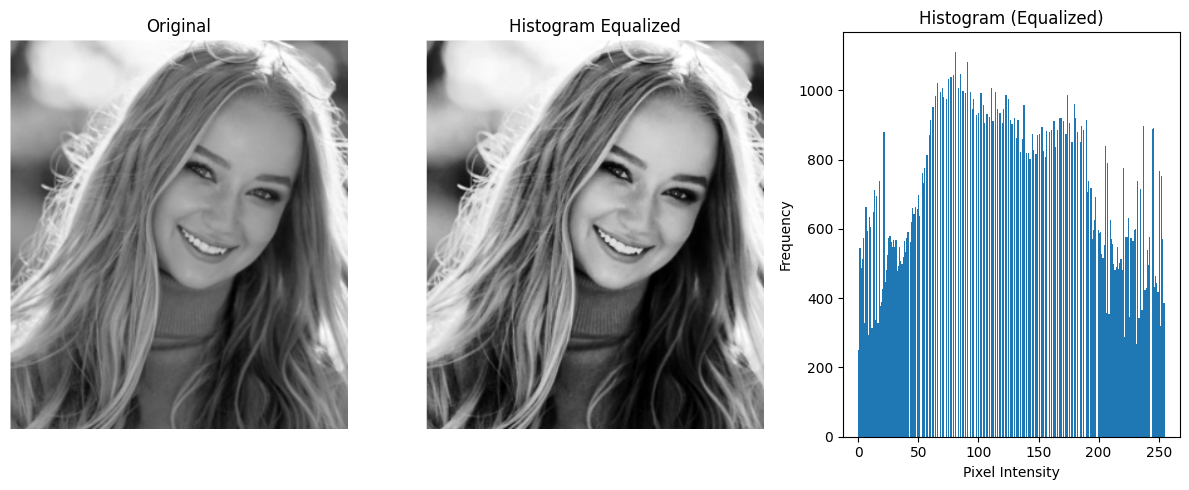

In [ ]:
import cv2
import matplotlib.pyplot as plt

filename = list(uploaded.keys())[0]

img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Image could not be loaded")
else:
    he_img = cv2.equalizeHist(img)

    plt.figure(figsize=(12,5))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(img, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Histogram Equalized")
    plt.imshow(he_img, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Histogram (Equalized)")
    plt.hist(he_img.ravel(), 256)
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

Program-2

Saving Screenshot 2026-08-17 123047.png to Screenshot 2026-08-17 123047.png
Optimal Threshold Value: 100.0


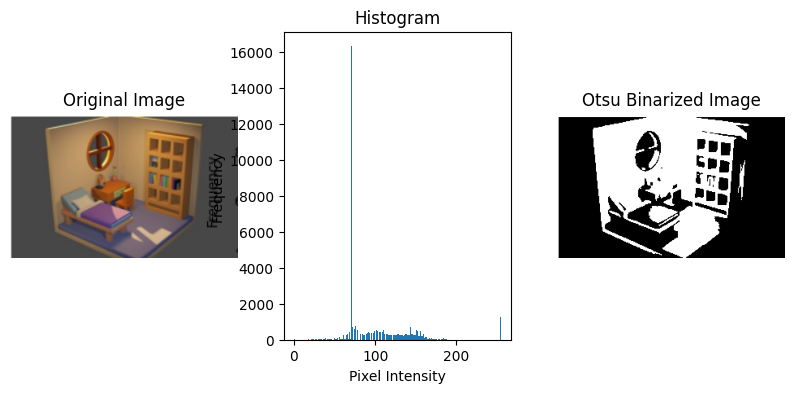

In [ ]:
#OpenCV reads images in BGR
#Matplotlib expects RGB
#PROGRAM 2: Image Segmentation
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
# Upload image
uploaded = files.upload()
# Get uploaded file name
image_path = list(uploaded.keys())[0]
# Read image in grayscale
img = cv2.imread(image_path, 0)
img_1 = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB)
if img is None:
    raise ValueError("Failed to load image!")
# Apply Otsu's Binarization
# Threshold value is automatically calculated
#threshold(src, thresh, maxval, type)
threshold_value, binary_img = cv2.threshold(
    img,
    100,
    255,
    #cv2.THRESH_BINARY + cv2.THRESH_OTSU #---- for using OTSU
    cv2.THRESH_BINARY
    #v2.THRESH_BINARY_INV
)
print("Optimal Threshold Value:", threshold_value)
# Display results
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Histogram")
plt.hist(img.ravel(), 256)
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.subplot(1,3,3)
plt.title("Otsu Binarized Image")
plt.imshow(binary_img, cmap='gray')
plt.axis("off")

plt.show()


Program-3

Saving Screenshot 2026-08-17 123424.png to Screenshot 2026-08-17 123424.png


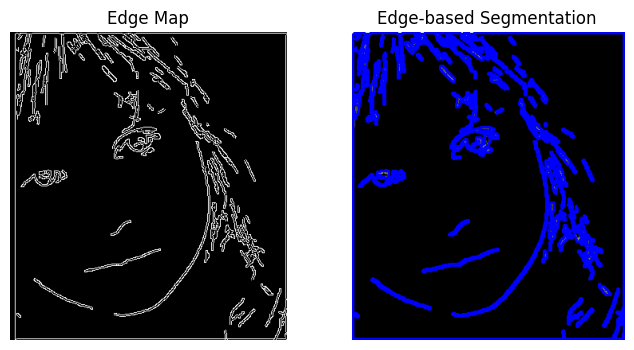

In [ ]:
#PROGRAM-3
#Edge Detection for Image Segmentation
import cv2
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# Read image in grayscale
img = cv2.imread(image_path, 0)
img_1 = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB)


if img is None:
    raise ValueError("Failed to load image!")

# Step 1: Edge detection
edges = cv2.Canny(img, 100, 200)

# Step 2: Find contours (segmentation)
#syntax-findContours(image, mode, method)
contours, _ = cv2.findContours(
    edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Convert to color to draw contours
segmented = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# Draw contours
cv2.drawContours(segmented, contours, -1, (0, 0, 255), 2)

# Display
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Edge Map")
plt.imshow(edges, cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Edge-based Segmentation",)
plt.imshow(segmented,cmap='gray')
plt.axis("off")

plt.show()

Saving Screenshot 2026-08-17 123504.png to Screenshot 2026-08-17 123504.png


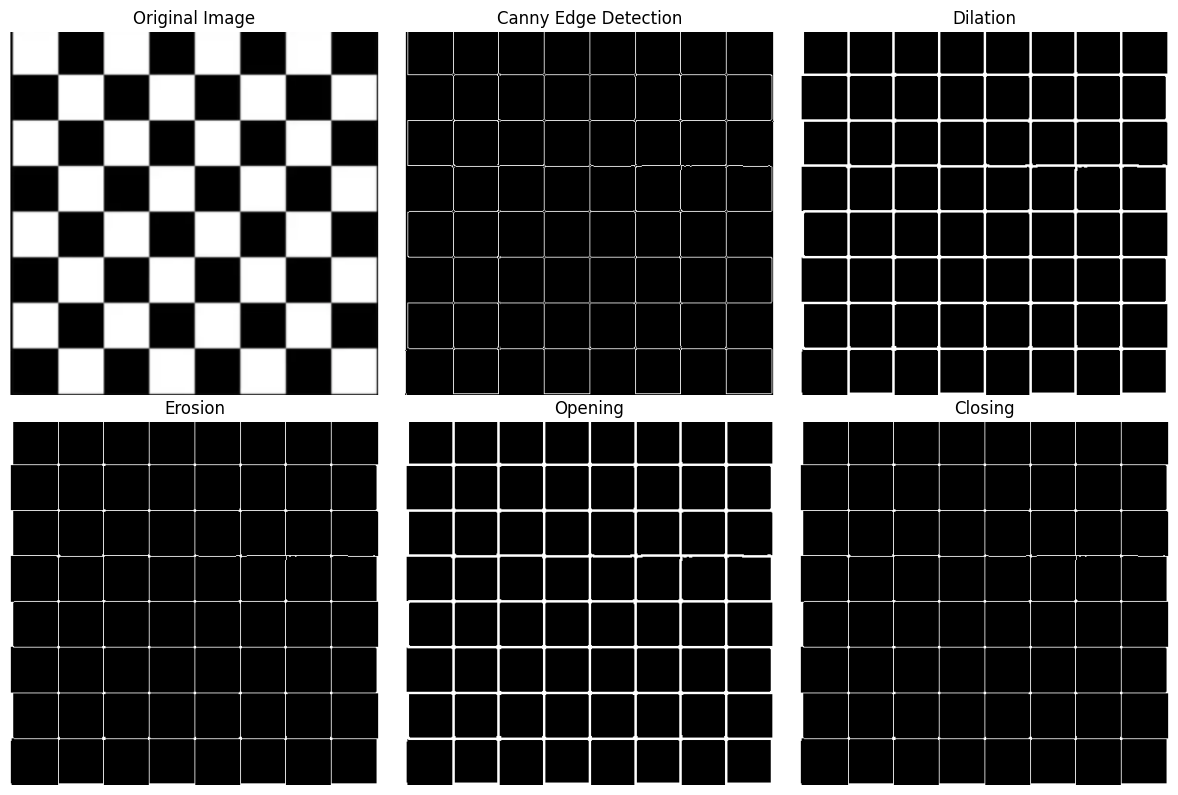

In [ ]:
#Morphological operations-process images based on shape and structure
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Read the image
# -----------------------------
from google.colab import files

# Upload image
uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# Read image in grayscale
img = cv2.imread(image_path, 0)
img_1 = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB)
# -----------------------------
# Step 2: Edge Detection (Canny)
# -----------------------------
edges = cv2.Canny(img, 100, 200)

# -----------------------------
# Step 3: Create Structuring Element
# -----------------------------
kernel = np.ones((3, 3), np.uint8)

# -----------------------------
# Step 4: Morphological Operations
# -----------------------------

# Dilation - thickens edges
dilated = cv2.dilate(edges, kernel, iterations=1)

# Erosion - thins edges / removes noise
eroded = cv2.erode(dilated, kernel, iterations=1)

# Opening - erosion followed by dilation
opening = cv2.morphologyEx(dilated, cv2.MORPH_OPEN, kernel)

# Closing - dilation followed by erosion
closing = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

# -----------------------------
# Step 5: Display Results
# -----------------------------
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("Canny Edge Detection")
plt.imshow(edges, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title("Dilation")
plt.imshow(dilated, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.title("Erosion")
plt.imshow(eroded, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.title("Opening")
plt.imshow(opening, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.title("Closing")
plt.imshow(closing, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()
